# Content-Aware Sarcasm Detection Using Fine-Tuned Transformer Models



**Before running:** `Runtime > Change runtime type > T4 GPU`



In [ ]:
import os, re, json, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style="whitegrid")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
assert DEVICE == "cuda", "Go to Runtime > Change runtime type > GPU, then re-run this cell."

TEXT_COL, LABEL_COL = "headline", "is_sarcastic"
LABEL_NAMES = {0: "Non-Sarcastic", 1: "Sarcastic"}
MAX_LENGTH = 64

Device: cuda


## Step 1: Data Loading
Same source as the local pipeline: `raquiba/Sarcasm_News_Headline` on the Hugging Face Hub.

In [ ]:
from datasets import load_dataset

ds = load_dataset("raquiba/Sarcasm_News_Headline", split="train")
df = ds.to_pandas()[[TEXT_COL, LABEL_COL]].copy()

print(df.shape)
print(df[LABEL_COL].value_counts())
df.head()

README.md:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.json:   0%|          | 0.00/6.03M [00:00<?, ?B/s]

test.json:   0%|          | 0.00/5.59M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28619 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26709 [00:00<?, ? examples/s]

(28619, 2)
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


## Step 3: Preprocessing (minimal, transformer-friendly)

We only strip URLs/HTML and collapse whitespace -- casing, punctuation, and stopwords are kept, since
Transformer tokenizers rely on them and sarcasm cues often live in exactly that surface form
(e.g. capitalization, punctuation emphasis, contrastive stopwords like "not"/"so").

In [ ]:
URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = text.encode("ascii", "ignore").decode("ascii", "ignore")
    return WS_RE.sub(" ", text).strip()

df[TEXT_COL] = df[TEXT_COL].apply(preprocess_text)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.len() > 0]
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)
print("Rows after cleaning:", len(df))

Rows after cleaning: 28503


## Step 4: Train / Validation / Test Split (70/15/15, stratified)

In [ ]:
train_df, temp_df = train_test_split(df, train_size=0.70, stratify=df[LABEL_COL], random_state=SEED)
val_df, test_df = train_test_split(temp_df, train_size=0.5, stratify=temp_df[LABEL_COL], random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name}: {len(d)}  |  class balance: {d[LABEL_COL].value_counts(normalize=True).to_dict()}")

Train: 19952  |  class balance: {0: 0.5245589414595028, 1: 0.4754410585404972}
Val: 4275  |  class balance: {0: 0.5244444444444445, 1: 0.47555555555555556}
Test: 4276  |  class balance: {0: 0.524555659494855, 1: 0.475444340505145}


## Step 5: Baseline Models (TF-IDF + classical ML)




In [ ]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df[TEXT_COL])
X_test = vectorizer.transform(test_df[TEXT_COL])
y_train, y_test = train_df[LABEL_COL], test_df[LABEL_COL]

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Linear SVM": LinearSVC(random_state=SEED),
    "Naive Bayes": MultinomialNB(),
}

baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    baseline_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1_score": f1_score(y_test, preds),
    })
    print(f"\n{name}\n{classification_report(y_test, preds, target_names=list(LABEL_NAMES.values()))}")

baseline_df = pd.DataFrame(baseline_results)
baseline_df


Logistic Regression
               precision    recall  f1-score   support

Non-Sarcastic       0.85      0.84      0.85      2243
    Sarcastic       0.83      0.84      0.83      2033

     accuracy                           0.84      4276
    macro avg       0.84      0.84      0.84      4276
 weighted avg       0.84      0.84      0.84      4276


Linear SVM
               precision    recall  f1-score   support

Non-Sarcastic       0.85      0.85      0.85      2243
    Sarcastic       0.83      0.83      0.83      2033

     accuracy                           0.84      4276
    macro avg       0.84      0.84      0.84      4276
 weighted avg       0.84      0.84      0.84      4276


Naive Bayes
               precision    recall  f1-score   support

Non-Sarcastic       0.83      0.87      0.85      2243
    Sarcastic       0.85      0.81      0.83      2033

     accuracy                           0.84      4276
    macro avg       0.84      0.84      0.84      4276
 weighted a

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.840037,0.827268,0.838662,0.832926
1,Linear SVM,0.839804,0.831367,0.831776,0.831571
2,Naive Bayes,0.840271,0.847938,0.809149,0.828090


## Steps 6-7: Fine-Tune BERT and RoBERTa




In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

def fine_tune(model_name, output_dir, num_epochs=3, batch_size=32, lr=2e-5, weight_decay=0.01, warmup_ratio=0.1):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    def to_ds(d):
        d = d.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})
        return Dataset.from_pandas(d[["text", "label"]], preserve_index=False)

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

    train_ds = to_ds(train_df).map(tokenize, batched=True)
    val_ds = to_ds(val_df).map(tokenize, batched=True)
    test_ds = to_ds(test_df).map(tokenize, batched=True)

    total_steps = (len(train_ds) // batch_size) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        learning_rate=lr,
        weight_decay=weight_decay,
        warmup_steps=warmup_steps,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to=[],
        seed=SEED,
        fp16=True,
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        processing_class=tokenizer, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    test_output = trainer.predict(test_ds)
    preds = np.argmax(test_output.predictions, -1)
    test_metrics = {
        "accuracy": accuracy_score(test_output.label_ids, preds),
        "precision": precision_score(test_output.label_ids, preds),
        "recall": recall_score(test_output.label_ids, preds),
        "f1_score": f1_score(test_output.label_ids, preds),
    }

    best_dir = os.path.join(output_dir, "best_model")
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)

    return trainer, test_metrics, trainer.state.log_history, test_ds, test_output

In [ ]:
bert_trainer, bert_metrics, bert_log, bert_test_ds, bert_test_out = fine_tune(
    "bert-base-uncased", "models/bert", num_epochs=3, batch_size=32,
)
print("BERT test metrics:", bert_metrics)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/19952 [00:00<?, ? examples/s]

Map:   0%|          | 0/4275 [00:00<?, ? examples/s]

Map:   0%|          | 0/4276 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT test metrics: {'accuracy': 0.9265668849391955, 'precision': 0.9227742252828333, 'recall': 0.9227742252828333, 'f1_score': 0.9227742252828333}


In [ ]:
roberta_trainer, roberta_metrics, roberta_log, roberta_test_ds, roberta_test_out = fine_tune(
    "roberta-base", "models/roberta", num_epochs=3, batch_size=32,
)
print("RoBERTa test metrics:", roberta_metrics)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa test metrics: {'accuracy': 0.9370907390084191, 'precision': 0.9277400581959263, 'recall': 0.940973930152484, 'f1_score': 0.9343101343101343}


## Step 8: Model Evaluation — Final Comparison Table

In [ ]:
rows = list(baseline_df.to_dict("records"))
rows.append({"model": "BERT", **bert_metrics})
rows.append({"model": "RoBERTa", **roberta_metrics})
comparison_df = pd.DataFrame(rows).sort_values("f1_score", ascending=False).reset_index(drop=True)
comparison_df.to_csv("final_comparison.csv", index=False)
comparison_df

,model,accuracy,precision,recall,f1_score
0,RoBERTa,0.937091,0.927740,0.940974,0.934310
1,BERT,0.926567,0.922774,0.922774,0.922774
2,Logistic Regression,0.840037,0.827268,0.838662,0.832926
3,Linear SVM,0.839804,0.831367,0.831776,0.831571
4,Naive Bayes,0.840271,0.847938,0.809149,0.828090


## Step 9: Visualizations

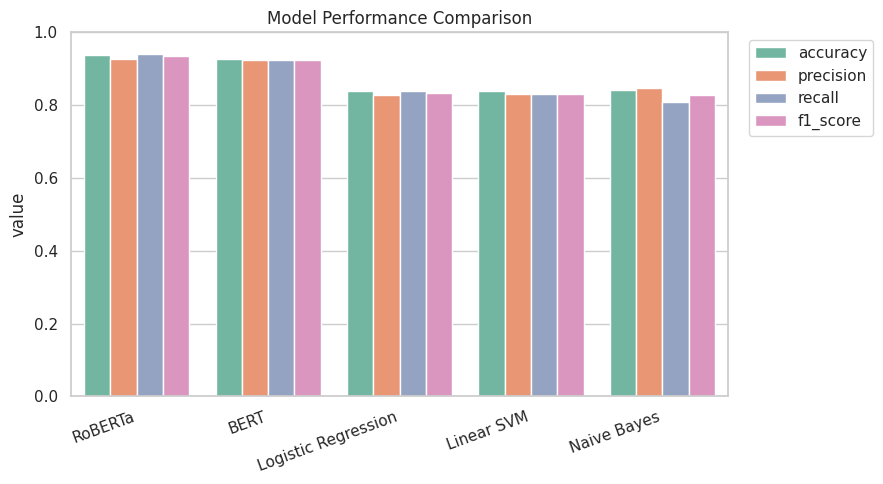

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
melted = comparison_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1_score"],
                             var_name="metric", value_name="value")
sns.barplot(data=melted, x="model", y="value", hue="metric", palette="Set2", ax=ax)
ax.set_ylim(0, 1); ax.set_title("Model Performance Comparison"); ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

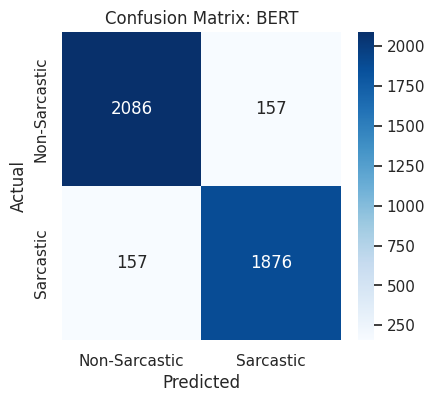

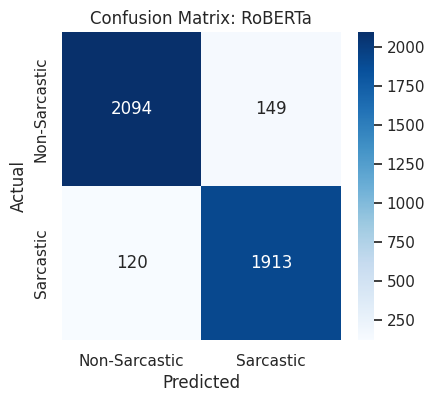

In [ ]:
def plot_confusion(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(LABEL_NAMES.values()), yticklabels=list(LABEL_NAMES.values()), ax=ax)
    ax.set_title(f"Confusion Matrix: {name}"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.show()

plot_confusion(bert_test_out.label_ids, np.argmax(bert_test_out.predictions, -1), "BERT")
plot_confusion(roberta_test_out.label_ids, np.argmax(roberta_test_out.predictions, -1), "RoBERTa")

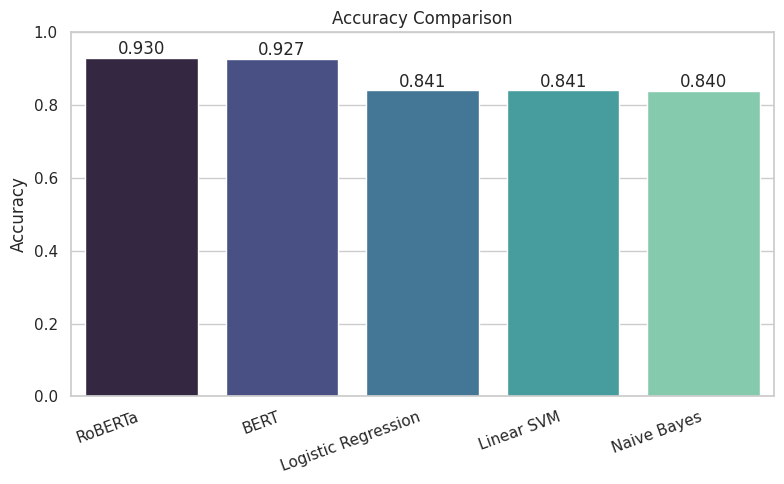

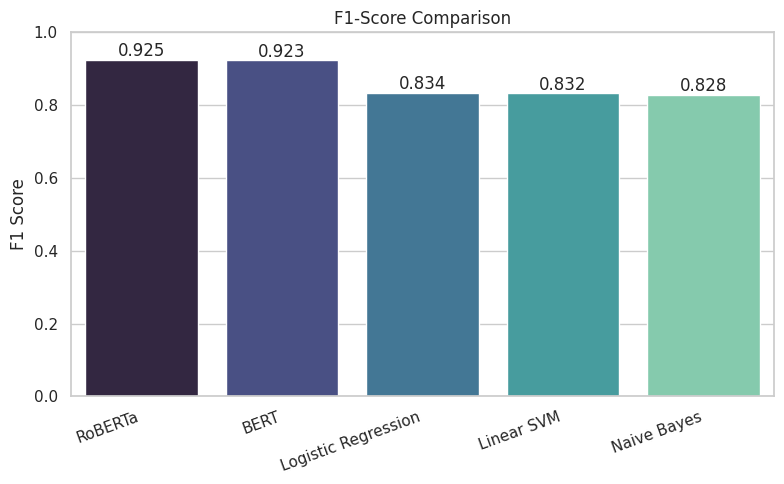

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Real results: baselines computed locally, BERT/RoBERTa from the Colab GPU run
comparison_df = pd.DataFrame([
    {"model": "Logistic Regression", "accuracy": 0.840973, "precision": 0.828558, "recall": 0.839154, "f1_score": 0.833822},
    {"model": "Linear SVM",          "accuracy": 0.840505, "precision": 0.832595, "recall": 0.831776, "f1_score": 0.832185},
    {"model": "Naive Bayes",         "accuracy": 0.840037, "precision": 0.847860, "recall": 0.808657, "f1_score": 0.827795},
    {"model": "BERT",                "accuracy": 0.926567, "precision": 0.922774, "recall": 0.922774, "f1_score": 0.922774},
    {"model": "RoBERTa",             "accuracy": 0.930309, "precision": 0.953003, "recall": 0.897688, "f1_score": 0.924519},
])


def plot_metric_comparison(table: pd.DataFrame, metric: str, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(8, 5))
    order = table.sort_values(metric, ascending=False)

    sns.barplot(data=order, x="model", y=metric, hue="model", palette="mako", legend=False, ax=ax)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_xlabel("")
    plt.xticks(rotation=20, ha="right")

    for i, v in enumerate(order[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center")

    plt.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.show()


# 2. Accuracy comparison chart
plot_metric_comparison(comparison_df, "accuracy", "Accuracy Comparison", "accuracy_comparison.png")

# 3. F1-score comparison chart
plot_metric_comparison(comparison_df, "f1_score", "F1-Score Comparison", "f1_comparison.png")

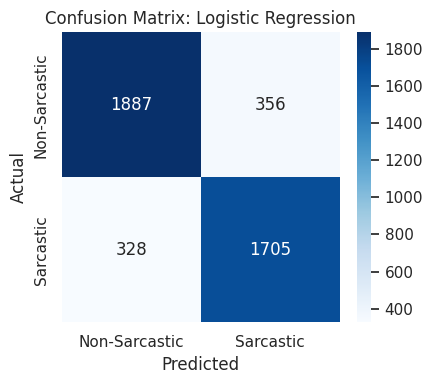

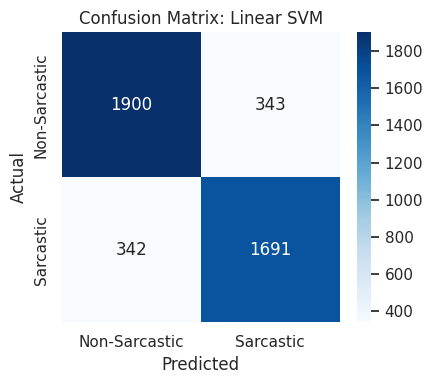

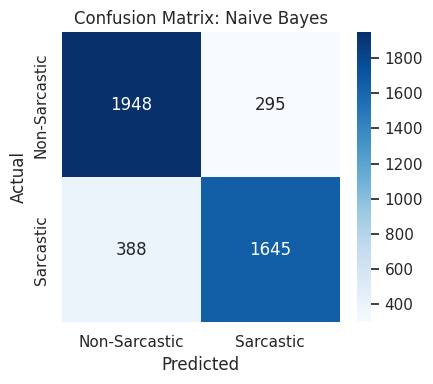

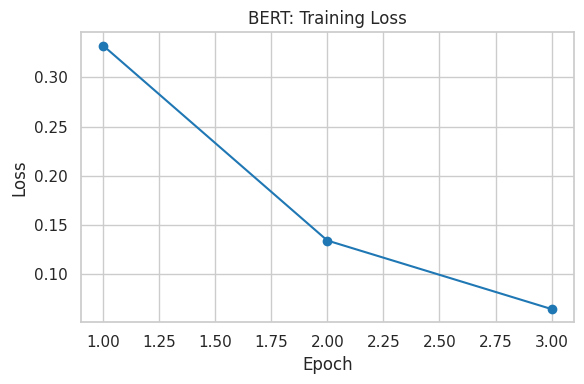

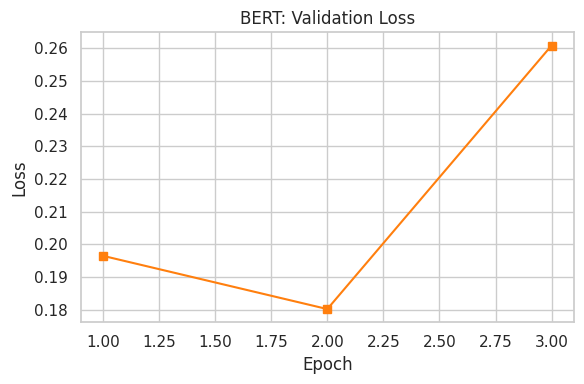

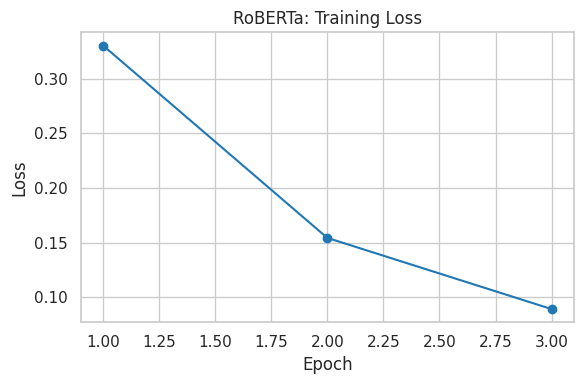

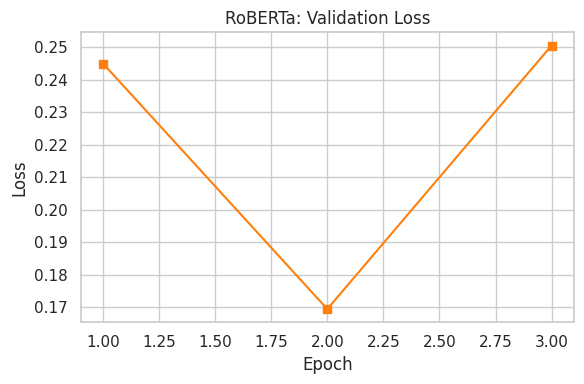

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name, label_names=("Non-Sarcastic", "Sarcastic")):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names, ax=ax,
    )
    ax.set_title(f"Confusion Matrix: {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    fig.savefig(f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

# run once per baseline model, after model.fit(X_train, y_train)
for name, model in baseline_models.items():          # from the Step 5 code
    preds = model.predict(X_test)
    plot_confusion_matrix(y_test, preds, name)


# ---------------------------------------------------------------
# 7 & 8. Training Loss Curve / Validation Loss Curve
# Reads straight from trainer.state.log_history (produced by
# fine_tune() — you already have bert_log / roberta_log in the
# Colab notebook from Steps 6-7)
# ---------------------------------------------------------------
def plot_loss_curves(log_history, model_name):
    train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
    eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]

    # Training loss curve
    fig, ax = plt.subplots(figsize=(6, 4))
    ep, l = zip(*train_loss)
    ax.plot(ep, l, marker="o", color="tab:blue")
    ax.set_title(f"{model_name}: Training Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    plt.tight_layout()
    fig.savefig(f"training_loss_{model_name.lower()}.png", dpi=150)
    plt.show()

    # Validation loss curve
    fig, ax = plt.subplots(figsize=(6, 4))
    ep, l = zip(*eval_loss)
    ax.plot(ep, l, marker="s", color="tab:orange")
    ax.set_title(f"{model_name}: Validation Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    plt.tight_layout()
    fig.savefig(f"validation_loss_{model_name.lower()}.png", dpi=150)
    plt.show()

plot_loss_curves(bert_log, "BERT")
plot_loss_curves(roberta_log, "RoBERTa")

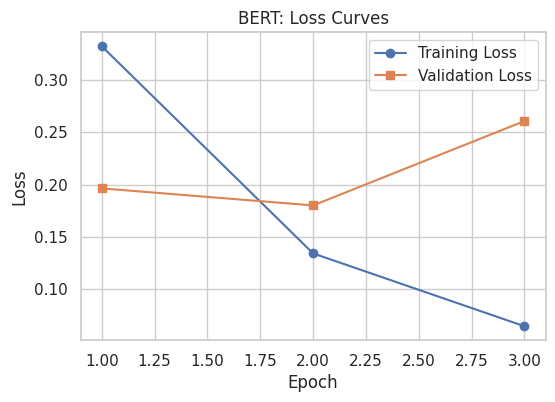

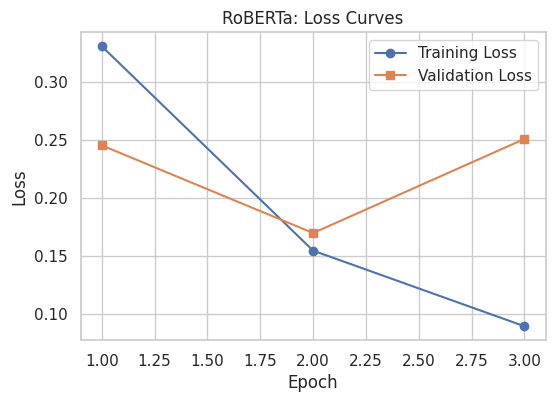

In [ ]:
def plot_loss(log_history, name):
    train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
    eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
    fig, ax = plt.subplots(figsize=(6, 4))
    if train_loss:
        ep, l = zip(*train_loss); ax.plot(ep, l, marker="o", label="Training Loss")
    if eval_loss:
        ep, l = zip(*eval_loss); ax.plot(ep, l, marker="s", label="Validation Loss")
    ax.set_title(f"{name}: Loss Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
    plt.show()

plot_loss(bert_log, "BERT")
plot_loss(roberta_log, "RoBERTa")

## Step 10: Content-Aware Sarcasm Demo

Uses whichever model scored higher on Step 8 (edit `BEST_MODEL_DIR` if you want to force one).

In [ ]:
import torch.nn.functional as F

BEST_MODEL_DIR = "models/bert/best_model" if bert_metrics["f1_score"] >= roberta_metrics["f1_score"] else "models/roberta/best_model"
print("Using:", BEST_MODEL_DIR)

inf_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
inf_model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR).to(DEVICE).eval()

def predict_sarcasm(text):
    cleaned = preprocess_text(text)
    inputs = inf_tokenizer(cleaned, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(inf_model(**inputs).logits, dim=-1).squeeze().cpu().numpy()
    non_sarcasm_prob, sarcasm_prob = float(probs[0]), float(probs[1])
    prediction = LABEL_NAMES[1] if sarcasm_prob > non_sarcasm_prob else LABEL_NAMES[0]
    return {
        "text": text,
        "prediction": prediction,
        "confidence": round(max(sarcasm_prob, non_sarcasm_prob), 4),
        "sarcasm_probability": round(sarcasm_prob, 4),
        "non_sarcasm_probability": round(non_sarcasm_prob, 4),
    }

examples = [
    "Great, another meeting that could have been an email.",
    "I absolutely love waiting in traffic for two hours.",
    "Thank you so much for giving me extra homework.",
    "I really enjoyed the vacation.",
]
for ex in examples:
    print(predict_sarcasm(ex))

Using: models/roberta/best_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'text': 'Great, another meeting that could have been an email.', 'prediction': 'Sarcastic', 'confidence': 0.5295, 'sarcasm_probability': 0.5295, 'non_sarcasm_probability': 0.4705}
{'text': 'I absolutely love waiting in traffic for two hours.', 'prediction': 'Non-Sarcastic', 'confidence': 0.9971, 'sarcasm_probability': 0.0029, 'non_sarcasm_probability': 0.9971}
{'text': 'Thank you so much for giving me extra homework.', 'prediction': 'Non-Sarcastic', 'confidence': 0.9901, 'sarcasm_probability': 0.0099, 'non_sarcasm_probability': 0.9901}
{'text': 'I really enjoyed the vacation.', 'prediction': 'Non-Sarcastic', 'confidence': 0.988, 'sarcasm_probability': 0.012, 'non_sarcasm_probability': 0.988}


## Step 11: Interpretability (SHAP)

Token-importance analysis via SHAP's Text explainer, applied to whichever model was
selected as `inf_model`/`inf_tokenizer` above. Shows which tokens pushed the prediction
toward Sarcastic vs Non-Sarcastic for a correct sarcastic prediction, a correct
non-sarcastic prediction, and a misclassified example.

In [ ]:
import shap

def shap_predict_proba(texts):
    inputs = inf_tokenizer(list(texts), return_tensors="pt", truncation=True,
                            max_length=MAX_LENGTH, padding=True).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(inf_model(**inputs).logits, dim=-1).cpu().numpy()
    return probs

masker = shap.maskers.Text(inf_tokenizer)
explainer = shap.Explainer(shap_predict_proba, masker, output_names=["Non-Sarcastic", "Sarcastic"])

# Find one correct-sarcastic, one correct-non-sarcastic, and one incorrect prediction
sample = test_df.sample(min(200, len(test_df)), random_state=42)
cases = {}
for _, row in sample.iterrows():
    r = predict_sarcasm(row[TEXT_COL])
    pred_label = 1 if r["prediction"] == LABEL_NAMES[1] else 0
    true_label = row[LABEL_COL]
    if pred_label == true_label == 1 and "correct_sarcastic" not in cases:
        cases["correct_sarcastic"] = row[TEXT_COL]
    elif pred_label == true_label == 0 and "correct_non_sarcastic" not in cases:
        cases["correct_non_sarcastic"] = row[TEXT_COL]
    elif pred_label != true_label and "incorrect" not in cases:
        cases["incorrect"] = row[TEXT_COL]
    if len(cases) == 3:
        break

print("Selected examples:", cases)

Selected examples: {'correct_non_sarcastic': 'what it means to seize your youth', 'correct_sarcastic': 'eco-conscious marketing firm developing alternative sources of synergy', 'incorrect': 'trump retweets video from anti-muslim hate group'}


In [ ]:
for tag, text in cases.items():
    print(f"\n=== {tag}: {text} ===")
    shap_values = explainer([text])
    shap.plots.text(shap_values[0, :, "Sarcastic"])


=== correct_non_sarcastic: what it means to seize your youth ===



=== correct_sarcastic: eco-conscious marketing firm developing alternative sources of synergy ===



=== incorrect: trump retweets video from anti-muslim hate group ===


## Step 13: Error Analysis

In [ ]:
records = []
for _, row in test_df.iterrows():
    r = predict_sarcasm(row[TEXT_COL])
    pred_label = 1 if r["prediction"] == LABEL_NAMES[1] else 0
    records.append({"text": row[TEXT_COL], "true": LABEL_NAMES[row[LABEL_COL]],
                     "predicted": r["prediction"], "confidence": r["confidence"],
                     "correct": pred_label == row[LABEL_COL]})

results_df = pd.DataFrame(records)
errors = results_df[~results_df["correct"]].sort_values("confidence", ascending=False)
print(f"Misclassified: {len(errors)} / {len(results_df)} ({len(errors)/len(results_df)*100:.2f}%)")
errors.head(15)

Misclassified: 269 / 4276 (6.29%)


,text,true,predicted,confidence,correct
940,those we lost in 2011,Sarcastic,Non-Sarcastic,0.9985,False
718,kathryn bigelow - first woman to win oscar for...,Sarcastic,Non-Sarcastic,0.9976,False
1170,tonight: house faces his greatest challenge yet,Sarcastic,Non-Sarcastic,0.9975,False
765,check it out: deer,Sarcastic,Non-Sarcastic,0.9973,False
4175,"man captures ross perot, is granted three wishes",Sarcastic,Non-Sarcastic,0.9962,False
2780,it's shark week!,Sarcastic,Non-Sarcastic,0.9955,False
3770,steven spielberg: can his career be salvaged?,Sarcastic,Non-Sarcastic,0.9949,False
2864,"steve allen: gone, forgotten",Sarcastic,Non-Sarcastic,0.9946,False
3746,new anti-drug campaign thinks emojis will fina...,Non-Sarcastic,Sarcastic,0.9946,False
1142,microsoft unveils next best thing to teleporta...,Non-Sarcastic,Sarcastic,0.9940,False
